In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from debyecalculator import DebyeCalculator
from ase.io import read
from pathlib import Path
import json
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Functions

# Rwp calculation
def Rwp(data, fit):
    """
    Calculate the weighted profile factor Rwp.
    """
    return np.sqrt(np.sum((data - fit)**2) / np.sum(data**2))

In [3]:
cif_folder = './models/4d_latentspace_split_latent_rep/'
cif_files_pred = sorted([str(f) for f in Path(cif_folder + 'predictions/').rglob('*.cif')])
cif_files_true = sorted([str(f) for f in Path(cif_folder + 'ground_truth/').rglob('*.cif')])

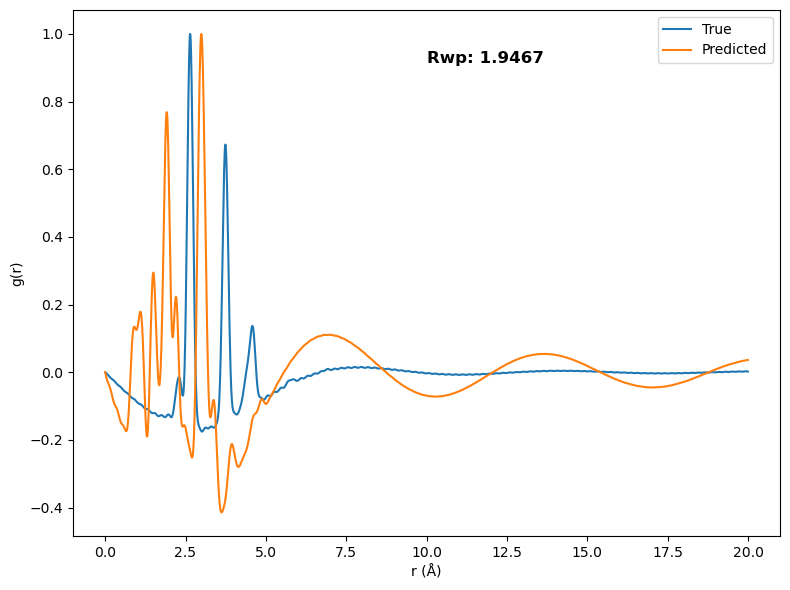

In [4]:
for index in range(len(cif_files_pred)):
    # Load the CIF file
    # index = 65
    cif_file_pred = cif_files_pred[index]
    cif_file_true = cif_files_true[index]
    # print(f'Loading CIF file: {cif_file_pred}')
    # print(f'Loading CIF file: {cif_file_true}')
    atoms_pred = read(cif_file_pred)
    atoms_true = read(cif_file_true)

    # Create the DebyeCalculator object
    debye_calc = DebyeCalculator(radiation_type='xray')

    pdf_pred = debye_calc.gr(atoms_pred, radii=30)
    pdf_true = debye_calc.gr(atoms_true, radii=30)

    # Normalize the PDF
    pdf_pred = np.array(pdf_pred)
    # pdf_pred[1] -= np.amin(pdf_pred[1])
    pdf_pred[1] /= np.amax(pdf_pred[1])
    # pdf_pred[1] -= np.amin(pdf_pred[1])

    pdf_true = np.array(pdf_true)
    # pdf_true[1] -= np.amin(pdf_true[1])
    pdf_true[1] /= np.amax(pdf_true[1])

    # pdf_pred[1] -= np.amin(pdf_true[1])
    # pdf_true[1] -= np.amin(pdf_true[1])

    # Calculate the Rwp
    rwp = Rwp(pdf_true[1], pdf_pred[1])

    # print(f'Rwp: {rwp}')

    # Plot the PDF
    plt.figure(figsize=(8, 6))
    plt.plot(pdf_true[0], pdf_true[1], label='True')
    plt.plot(pdf_pred[0], pdf_pred[1], label='Predicted')
    plt.annotate(f'Rwp: {rwp:.4f}', xy=(0.5, 0.9), xycoords='axes fraction', fontsize=12, fontweight='bold')
    plt.xlabel('r (Å)')
    plt.ylabel('g(r)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    break

In [5]:
# Read json files 
with open(cif_folder + 'CrystalTypeAnalysis/losses.json') as f:
    loss_json = json.load(f)
    
with open(cif_folder + 'CrystalTypeAnalysis/reconstructions.json') as f:
    rec_json = json.load(f)

# Convert to pandas dataframe
loss_df = pd.DataFrame(loss_json)
rec_df = pd.DataFrame(rec_json)

In [6]:
rec_df

,crystalType,n_atoms,n_oxygens,n_metals,cell_parameters,cell_positions,cell_atoms,latent_space_mean,latent_space_std
0,RheniumTrioxide,4,3,1,"[3.1873607635498047, 3.3467936515808105, 4.844...","[[0.04288246110081673, 0.05649369955062866, 0....","[2, 1, 1, 1]","[-106.25234985351562, 15.936240196228027, 46.7...","[12.256085395812988, 57.76818084716797, 12.497..."
1,Wurtzite,12,8,4,"[4.926783561706543, 4.94049072265625, 5.179255...","[[0.11171102523803711, 0.09528292715549469, 0....","[2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1]","[-1.3501734733581543, -0.03236669301986694, 0....","[0.6304934024810791, 1.965806245803833, 0.3705..."
2,CaesiumChloride,4,3,1,"[3.3893442153930664, 3.4791483879089355, 4.568...","[[0.05310450866818428, 0.06604605913162231, -0...","[2, 1, 1, 1]","[-81.43241882324219, 11.784660339355469, 37.05...","[10.394393920898438, 40.825172424316406, 11.23..."
3,RheniumTrioxide,6,5,1,"[3.91096830368042, 3.9668221473693848, 4.18316...","[[0.04886408522725105, 0.052763521671295166, -...","[2, 1, 1, 1, 1, 1]","[-66.430908203125, 12.125910758972168, 35.6040...","[12.473194122314453, 36.06023025512695, 8.4311..."
4,RheniumTrioxide,4,3,1,"[3.2066242694854736, 3.3458828926086426, 4.760...","[[0.043898824602365494, 0.06367868185043335, -...","[2, 1, 1, 1]","[-92.12765502929688, 13.720392227172852, 40.65...","[10.846940994262695, 49.779109954833984, 10.89..."
...,...,...,...,...,...,...,...,...,...
313,RockSalt,8,4,4,"[4.317366600036621, 4.355799198150635, 5.93854...","[[0.04339797422289848, 0.043575018644332886, 0...","[2, 2, 2, 2, 1, 1, 1, 1]","[-31.54116439819336, 5.18039083480835, 17.5001...","[5.715180397033691, 18.74239730834961, 3.36016..."
314,NickelArsenide,6,5,1,"[3.0631699562072754, 3.1887552738189697, 4.790...","[[0.05110913887619972, 0.05979716777801514, 0....","[2, 1, 1, 1, 1, 1]","[-87.79480743408203, 13.06623649597168, 40.046...","[11.149809837341309, 43.22806167602539, 12.733..."
315,Rutile,8,6,2,"[4.2329020500183105, 4.289201736450195, 4.0675...","[[0.03155862167477608, 0.031165897846221924, 0...","[2, 2, 1, 1, 1, 1, 1, 1]","[-39.790828704833984, 5.750967025756836, 18.42...","[5.852167129516602, 19.256624221801758, 5.3775..."
316,Wurtzite,9,5,4,"[4.362503528594971, 4.38656759262085, 5.928696...","[[0.04540326073765755, 0.06113217771053314, 0....","[2, 2, 2, 2, 1, 1, 1, 1, 1]","[-26.312679290771484, 4.881372451782227, 12.12...","[2.527824878692627, 15.359274864196777, 3.1550..."


In [7]:
# Plot the latent space
latent_space_means = np.array(rec_df['latent_space_mean'].to_list())
latent_space_stds = np.array(rec_df['latent_space_std'].to_list())

In [8]:
latent_means_cell_params = latent_space_means[:, :2]
latent_stds_cell_params = latent_space_stds[:, :2]

latent_means_cell_content = latent_space_means[:, 2:]
latent_stds_cell_content = latent_space_stds[:, 2:]

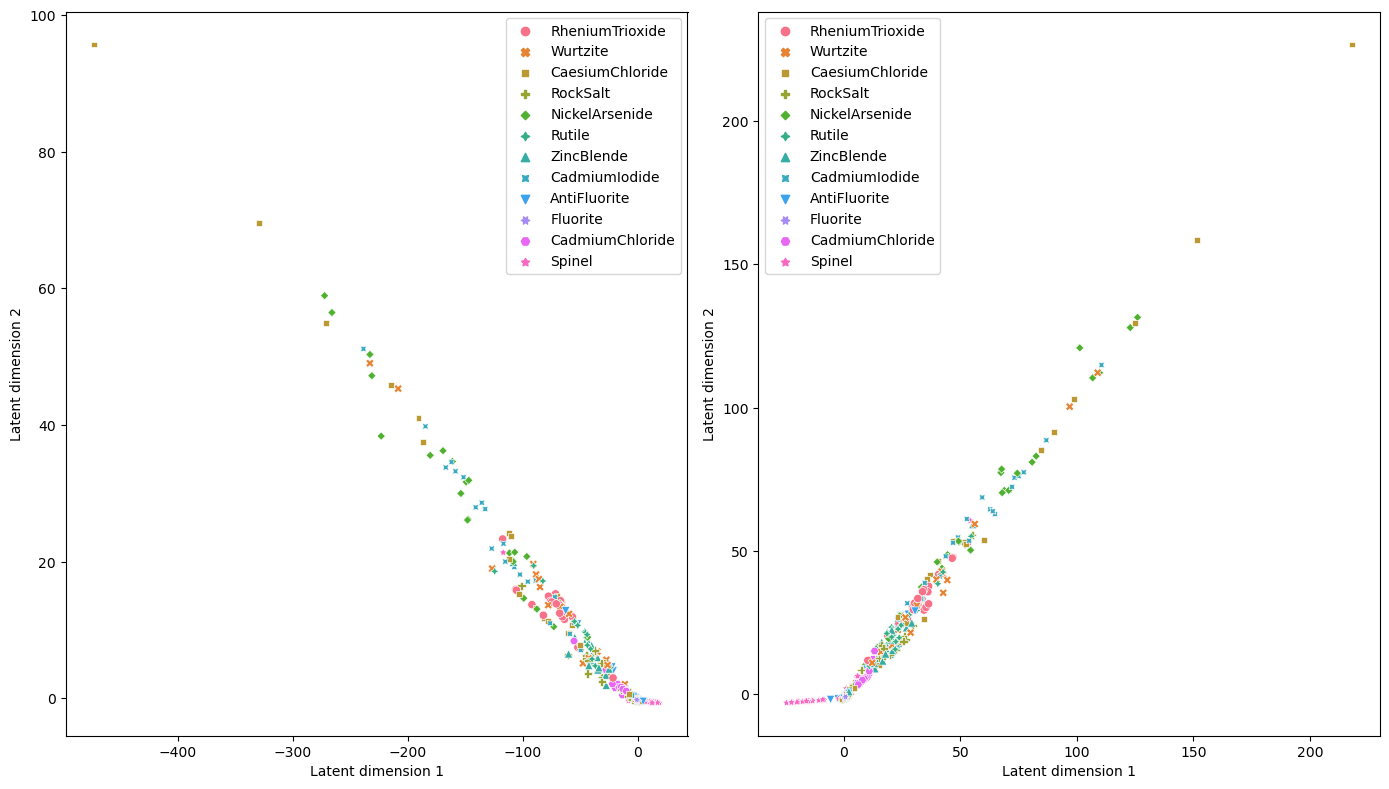

In [9]:
# Plot the latent spaces
fig, ax = plt.subplots(1, 2, figsize=(14, 8))
sns.scatterplot(x=latent_means_cell_params[:, 0], y=latent_means_cell_params[:, 1], hue=rec_df['crystalType'], style=rec_df['crystalType'], ax=ax[0])
sns.scatterplot(x=latent_means_cell_content[:, 0], y=latent_means_cell_content[:, 1], hue=rec_df['crystalType'], style=rec_df['crystalType'], ax=ax[1])
ax[0].set_xlabel('Latent dimension 1')
ax[0].set_ylabel('Latent dimension 2')
ax[1].set_xlabel('Latent dimension 1')
ax[1].set_ylabel('Latent dimension 2')

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

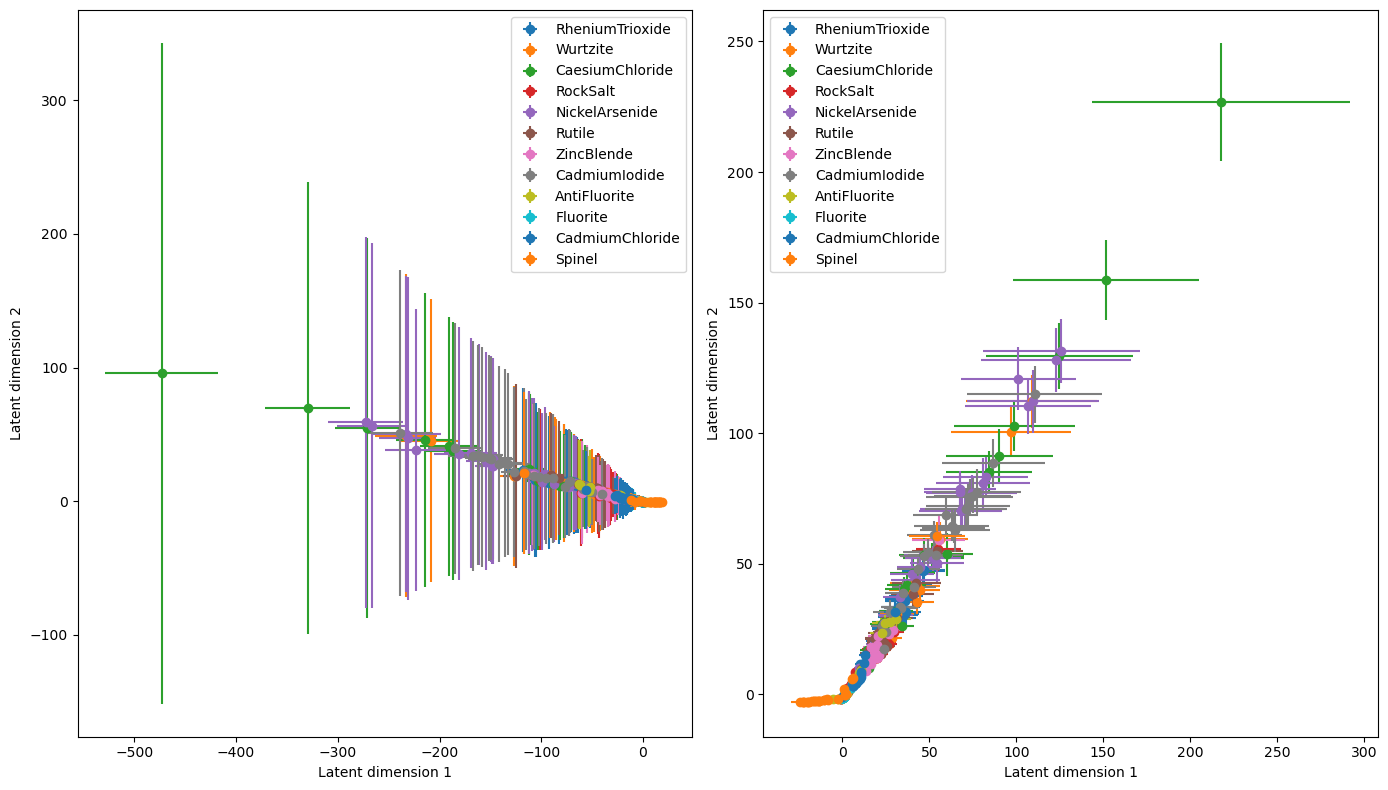

In [20]:
# Plot the latent spaces
fig, ax = plt.subplots(1, 2, figsize=(14, 8))

for crystal_type in rec_df['crystalType'].unique():

    crystal_type_filter = (rec_df['crystalType'] == crystal_type)

    ax[0].errorbar(latent_means_cell_params[:, 0][crystal_type_filter], latent_means_cell_params[:, 1][crystal_type_filter], xerr=latent_stds_cell_params[:, 0][crystal_type_filter], yerr=latent_stds_cell_params[:, 1][crystal_type_filter], fmt='o', label=crystal_type)
    ax[1].errorbar(latent_means_cell_content[:, 0][crystal_type_filter], latent_means_cell_content[:, 1][crystal_type_filter], xerr=latent_stds_cell_content[:, 0][crystal_type_filter], yerr=latent_stds_cell_content[:, 1][crystal_type_filter], fmt='o', label=crystal_type)

ax[0].set_xlabel('Latent dimension 1')
ax[0].set_ylabel('Latent dimension 2')
ax[1].set_xlabel('Latent dimension 1')
ax[1].set_ylabel('Latent dimension 2')

ax[0].legend()
ax[1].legend()

# ax[0].set_xlim(-10, 10)
# ax[0].set_ylim(-10, 10)
# ax[1].set_xlim(-10, 10)
# ax[1].set_ylim(-10, 10)

plt.tight_layout()
plt.show()

In [19]:
latent_space_stds[:, 1][crystal_type_filter]

array([ 0.37196887,  5.88899183,  0.32565737,  2.67107439,  0.26022086,
        0.40922737,  2.32634354,  0.20553568,  2.57117295,  0.1631733 ,
        0.51207244,  0.25081477,  0.51348907,  0.40726376,  0.19352856,
        0.60450125, 60.63788223,  0.29412436,  0.2396818 ,  0.54422975,
        0.19560613,  0.90268517,  2.9391253 ,  5.49360275,  0.4149895 ,
        0.35960579,  0.34180659])